In [ ]:
import pandas as pd
import numpy as np   
from sklearn.model_selection import train_test_split
import math
from collections import OrderedDict,Counter
from kmapper.plotlyviz import *
import gower as gw
from sklearn.metrics.pairwise import cosine_distances,pairwise_distances
from sklearn import preprocessing
import seaborn as sb
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS, SpectralEmbedding
import tensorflow as tf
import kmapper as km
import ast
from sklearn.cluster import AgglomerativeClustering,SpectralClustering,DBSCAN
#from sklearn_extra.cluster import KMedoids
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
import time
import argparse
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
from sklearn.neighbors import NearestNeighbors
from matplotlib.gridspec import GridSpec
import joblib
import matplotlib

In [4]:
def distance_matrix_computation(patient_id, Y_class, dataset, continue_features):
    """
    Function for distance matrix calculation, according to the features' type.
    Distance matrix will be saved into ./data/trainingset_distance_matrix.npy
    INPUT:
        - patient_id:           (pandas Series) dataset's column indicating the samples IDs
        - Y_class:              (pandas Series) dataset's column indicating the initial phenotypes
        - dataset               (pandas DataFrame) dataset for which calculate the distance
        - continue_features     (list) list containing the dataset's numerical features
    OUTPUT:
        - distance_matrix       (numpy ndarray) patients distance matrix
    """
    
    # filter the dataset in order to delete the IDs and the output columns
    dataset_features = dataset.loc[:, ~dataset.columns.isin([patient_id.name,Y_class.name])]
    
    # find all the categorical variables
    bool_categorical = []
    for features in list(dataset_features.columns):
        if features in continue_features:
            bool_categorical.append(False)
        else:
            bool_categorical.append(True)
    
    # only categorical variables -> Jaccard distance
    if sum(bool_categorical) == 0:
        print("only categorical variables -> Jaccard distance")
        
        # make the categorical variables as dummies
        df_categorical_dummies = pd.get_dummies(dataset_features.astype(str),drop_first=True)
        distance_matrix = pairwise_distances(df_categorical_dummies.values, metric = "jaccard")
    
    
    # both categorical and continue variables -> Gower distance
    elif sum(bool_categorical)>0 and sum(bool_categorical)!=len(bool_categorical):
        print("both categorical and continue variables -> Gower distance")
        
        # the gower package already creates dummy variables and standardize numerical variables
        distance_matrix = gw.gower_matrix(dataset_features,cat_features=bool_categorical)
        
        
    # only numerical variables -> cosine distance 
    elif sum(bool_categorical)==len(bool_categorical):
        print("only numerical variables -> cosine distance")
        
        # scaling the numerical features in [0,1] range
        X = dataset_features.values
        min_max_scaler = preprocessing.MinMaxScaler()
        X_scaled = min_max_scaler.fit_transform(X)
        dataset_scaled= pd.DataFrame(X_scaled, columns = dataset_features.columns)

        distance_matrix = cosine_distances(dataset_scaled,dataset_scaled)
        
    # save the distance matrix as .npy file
    np.save("./distance_matrix",distance_matrix,allow_pickle=False)
    
    return distance_matrix



def estimate_dbscan_params(data, smooth_n=1000):
    """
    Estimate optimal DBSCAN parameters (`eps` and `minPts`) using the elbow method and log rule.
    
    Parameters:
    - datadf: (pandas DataFrame) dataset of interest
    - smooth_n: Number of interpolation points for smoother elbow curve (default: 1000)
    
    Returns:
    - eps_estimated: float, estimated `eps` value
    - minPts: int, estimated `minPts` value
    """

    n_samples = data.shape[0]
    minPts = int(np.round(np.log(n_samples)))

    # Use k+1 because kNN includes the point itself
    nbrs = NearestNeighbors(n_neighbors=minPts + 1).fit(data)
    distances, _ = nbrs.kneighbors(data)

    # Get the k-th nearest distance (excluding self-distance)
    k_distances = np.sort(distances[:, minPts])

    # Interpolate to smooth the curve
    x_vals = np.linspace(0, len(k_distances) - 1, smooth_n)
    interpolator = interp1d(np.arange(len(k_distances)), k_distances, kind='linear')
    y_vals = interpolator(x_vals)

    # First and second derivative for elbow detection
    dy = np.gradient(y_vals, x_vals)
    d2y = np.gradient(dy, x_vals)

    # Find the elbow as the maximum second derivative
    elbow_idx = np.argmax(np.abs(d2y))
    eps_estimated = y_vals[elbow_idx]

    return eps_estimated, minPts



def entropy_count(scomplex, initial_class, make_the_class_binary, control_value):
    """
    Function for computing the graph entropy.
    INPUT:
       - scomplex:     (dictionary) simplicial complex resulting from the application of KeplerMapper
       - initial_class: (pandas Series) dataset's column indicating the initial phenotypes
       - make_the_class_binary: (Boolean) if True, makes the class binary only for the computation of the entropy,
                                          with controls the value in control_value; cases are all the others values and grouped
       - control_value: (int)   which value of the initial_class to use as controls
    OUTPUT:
       - entropy: (float) graph entropy (weighted mean average nodes entropy)
    """
    

    initial_class_ = initial_class.copy(True)

    # check if class need to be binarized with values [0,1], where 0 indicates the controls and 1 the cases
    if make_the_class_binary:

        # define the controls and label them with 0
        initial_class_ = initial_class_.replace(to_replace=control_value,value=0)

        # define the cases and label with 1
        for case_label in initial_class_.value_counts().index:
            if case_label!=0:
                initial_class_ = initial_class_.replace(to_replace=case_label,value=1)

    kmgraph = get_mapper_graph(scomplex)
    # assign to node['custom_tooltips']  the node label
    for node in kmgraph[0]['nodes']:
        node['label'] = initial_class_[scomplex['nodes'][node['name']]]
    entropy_node = {}

    label_values = list(initial_class_.value_counts().index)
    label_values.sort()

    # extract nodes properties such as size and how many samples for each class
    for j, node in enumerate(kmgraph[0]['nodes']):   
        dimCluster = node['cluster']['size']
            
        data_bin = node['label']

        dimData_dict = {}
        for label in label_values:
            dimData_dict[label] = len(data_bin.loc[data_bin==label])

        # compute the entropy by looking at each label frequency
        H_node = 0.0
        for k,v in dimData_dict.items():
            # only if the label is present in the node!
            if v != 0:
                H_node+=  -(v/dimCluster)*math.log2(v/dimCluster)
                
        entropy_node[j] = [dimCluster, H_node]
        
    # compute the average weighted entropy -> graph entropy        
    sumBinEntropies = 0
    numberData = 0
    for j, node in enumerate(entropy_node):
        sumBinEntropies += (entropy_node[j][0]*entropy_node[j][1])
        numberData += entropy_node[j][0]
    graph_entropy = sumBinEntropies/numberData
    
    return graph_entropy


def do_hist_counter(scomplex):

    """
    Function to calculate the nodes size distribution.
    INPUT:
       - scomplex: (dictionary) simplicial complex resulting from the application of KeplerMapper
    OUTPUT:
       - counter:  (list) list of integer containing the distribution of the nodes size
       - n_nodes:  (int)  number of graph nodes
       - n_edges:  (int)  number of graph edges
       - n_unique: (int)  number of unique samples (patients) that results in the simplicial commplex
    """    
    kmgraph,  mapper_summary, colorf_distribution = get_mapper_graph(scomplex,
                                                                 color_function_name='Distance to x-min')

    n_nodes = mapper_summary['n_nodes']
    n_edges = mapper_summary['n_edges']
    n_unique = mapper_summary['n_unique']
    
    counter = list()
    for j, node in enumerate(kmgraph['nodes']):
        counter.append(node["cluster"]["size"])

    return counter,n_nodes,n_edges,n_unique

In [5]:
def lenses_and_hyperparameters_greedy_search(distance_matrix,lens_names, projection_dimension, make_the_class_binary, control_value,
                                              perplexities,learning_rates,n_iters,
                                              min_dists,n_neighbors,
                                              n_neurons,n_layers,nlayerdeep,nneurons_start,       
                                              n_cubes,perc_overlap,cluster_methods,
                                              rnd,initial_class, biological_features, path_grid_search_results,
                                              flag_remove_duplicate_nodes):
    """
    Function for the lens functions and their hyperparameters grid search. 
    The execution time (in minutes) is printed at the end.
    INPUT:
       - distance_matrix:      (numpy ndarray) patients distance matrix
       - lens_names:           (list) list with the lens functions to include in the grid search
       - projection_dimension: (int) integer that indicates the number of dimensios of the projected space
       
       t-SNE parameters as sklearn
       - [ perplexities (list of int) ; learning_rates (list of int) ; n_iters (list of int) ]
       UMAP parameters as umap-learn
       - [ min_dists (list of float) ; n_neighbors (list of int) ]
       UMAPnn (encoder as ParametricUMAP) parameters as umap-learn
       - [ n_neurons (list of int) ; n_layers (list of int) ]
       UMAPae (autoencoder as ParametricUMAP) parameters as umap-learn
       - [ nlayerdeep (list of int) ; nneurons_start (list of int) ]
       
       - n_cubes:         (list of int) list of number of hypercubes for each project dimensions, i.e. resolution
       - perc_overlap:    (list of float) list of percentages of overalap, i.e. gain
       - cluster_methods: (list of sklearn cluster methods) list of cluster methods to use in the grid search
       
       - rnd: (int) seed for reproducible output
       - initial_class: (pandas Series) dataset's column indicating the initial phenotypes
       - biological_features: (pandas DataFrame) a DataFrame with two columns to use as biological lens.
                              The first column will be used as projection with l2 if specifying "Bio_l2" lens;  
                              Both columns will be used as projections if specifying "Bio_bio" lens.
       - path_grid_search_results: (string) path in which the output dataframe will be saved
       - flag_remove_duplicate_nodes (boolean) if eliminate duplicated node in the mapper
    OUTPUT:
       - grid_search_results_df: (pandas DataFrame) report of the grid search 
    """
    
    # start by creating an empy dataframe. This will be appended with the grid search combinations of parameters and graph statistics
    grid_search_results_df = pd.DataFrame(columns = ["lens_name","parameters_combination",
                            "n_nodes","n_edges","n_unique","graph_entropy",
                            "node_size_distribution_values", "mean_size",
                            "nodes_degree", "mean_degree", "density"])
    st = time.time()
    mapper = km.KeplerMapper()    

    # cicle on all the lens functions specified in the list. 
    # For each functions all the parameters combination are tried, a projection lens in created and the dataset is projected
    # then the projection are used by the 'Mapper_hyperparameters_greedy_search' functions to create the graph
    
    for lens in lens_names:
        
        print("lens: "+lens)
        
       
        if lens=="PCA":
            projection = mapper.project(distance_matrix, projection=PCA(n_components=projection_dimension, random_state=rnd), distance_matrix = None, scaler = None)
            
            parameters_combination_string = "-" 
            grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
                
            
        if lens=="tSNE":
            for p in perplexities:
                for l in learning_rates:
                    for i in n_iters:
                        print("perplexity: "+ str(p)+"; learning_rates: "+ str(l) +"; n_iters: "+ str(i)   )
                        projection = mapper.project(distance_matrix, projection= TSNE(n_components=projection_dimension, random_state=rnd, perplexity = p , learning_rate= l , n_iter= i,init="random",metric="precomputed"),distance_matrix = None, scaler = None)

                        parameters_combination_string = str("perplexity: "+ str(p)+"; learning_rates: "+ str(l) +"; n_iters: "+ str(i)) 
                        grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection, make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
                
    
                        
        if lens=="UMAP": 
            for n in n_neighbors:
                for d in min_dists:
                    print("min_dists: "+ str(d)+"; n_neighbors: "+ str(n))
                    projection = mapper.project(distance_matrix, projection= umap.UMAP(n_components=projection_dimension, random_state=rnd, n_neighbors= n, min_dist=d,metric="precomputed"),distance_matrix = None, scaler = None)

                    parameters_combination_string = str("min_dists: "+ str(d)+"; n_neighbors: "+ str(n)) 
                    grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)

                        
        
        if lens=="UMAPnn": 
            
            for nN in n_neurons:
                for nl in n_layers:
                    print("n_neurons: "+ str(nN)+"; n_layers: "+ str(nl))
                    parameters_combination_string = str("n_neurons: "+ str(nN)+"; n_layers: "+ str(nl)) 
                    
                    encoder = tf.keras.Sequential([
                
                    tf.keras.layers.InputLayer(input_shape=distance_matrix.shape[1]),
                    tf.keras.layers.Flatten()])
                    
                    for nn in range(nl):
                
                        encoder.add(tf.keras.layers.Dense(units=nN, activation="relu"))
                    
                    encoder.add(tf.keras.layers.Dense(units=projection_dimension, name="z"))
                
            
                    projection = mapper.project(distance_matrix, projection= ParametricUMAP(keras_fit_kwargs = keras_fit_kwargs,encoder=encoder),distance_matrix = None, scaler = None)
                    grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
            
        if lens=="UMAPae":
        
                
            for ndeep in nlayerdeep:
                for init_dim in nneurons_start:
                    
                    print("nlayerdeep: "+ str(ndeep)+"; nneurons_start: "+ str(init_dim))
                    parameters_combination_string = str("nlayerdeep: "+ str(ndeep)+"; nneurons_start: "+ str(init_dim)) 
                    
                    encoder = tf.keras.Sequential([
                
                    tf.keras.layers.InputLayer(input_shape=distance_matrix.shape[1]),
                    tf.keras.layers.Flatten()])
            
                    decoder = tf.keras.Sequential([
                
                    tf.keras.layers.InputLayer(input_shape=projection_dimension)])
                    
                    start_dim = init_dim
                    reverse_start_dim = init_dim/(2**(ndeep-1))
                    for nn in range(ndeep):
                
                        encoder.add(tf.keras.layers.Dense(units=int(start_dim), activation="relu"))
                        start_dim = start_dim/2
                
                        decoder.add(tf.keras.layers.Dense(units=int(reverse_start_dim), activation="relu"))
                        reverse_start_dim = reverse_start_dim*2
                        
                    
                    encoder.add(tf.keras.layers.Dense(units=projection_dimension, name="z"))
                    decoder.add(tf.keras.layers.Dense(units=np.product(distance_matrix.shape[1]), name="recon", activation=None))
                    decoder.add(tf.keras.layers.Reshape((distance_matrix.shape[1],1)))
                
        
                    projection = mapper.project(distance_matrix, projection= ParametricUMAP(keras_fit_kwargs = keras_fit_kwargs,parametric_reconstruction= True,autoencoder_loss = True,encoder=encoder,decoder=decoder),distance_matrix = None, scaler = None)
                    grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
     
    
        if lens=="Bio_l2":
            
                print(biological_features.iloc[:,0].name + "l2 norm")
                parameters_combination_string = biological_features.iloc[:,0].name
            
                bio_feature = np.array(biological_features.iloc[:,0]).reshape((biological_features.iloc[:,0].shape[0], 1))
                lens2 = mapper.fit_transform(distance_matrix, projection="l2norm", distance_matrix = None, scaler = None)
                projection = np.c_[lens2, bio_feature]
                
                grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
     
        if lens=="Bio_bio":
                print(biological_features.iloc[:,0].name + " " + biological_features.iloc[:,1].name)
                parameters_combination_string = biological_features.iloc[:,0].name + " " + biological_features.iloc[:,1].name
    
                bio_feature_1 = np.array(biological_features.iloc[:,0]).reshape((biological_features.iloc[:,0].shape[0], 1))
                bio_feature_2 = np.array(biological_features.iloc[:,1]).reshape((biological_features.iloc[:,1].shape[0], 1))
                projection = np.c_[bio_feature_1, bio_feature_2]
                
                grid_search_results_df = Mapper_parameters_greedy_search(distance_matrix,mapper,projection,make_the_class_binary, control_value,
                                                         n_cubes,perc_overlap,cluster_methods, 
                                                         lens, parameters_combination_string,grid_search_results_df,initial_class,flag_remove_duplicate_nodes)
     
    
    
    grid_search_results_df.to_excel(path_grid_search_results,index=False)
    
    et = time.time()
    elapsed_time = (et - st)/60
    print('Execution time:', elapsed_time, 'minutes')
    
    return grid_search_results_df

def Mapper_parameters_greedy_search(distance_matrix,mapper,projection, make_the_class_binary, control_value,
                         n_cubes,perc_overlap,cluster_methods,
                        lens, parameters_string_combination, grid_search_results_df,initial_class,flag_remove_duplicate_nodes):
    """
    Function for the Mapper parameters (resolution, gain and clustering algorithm) grid search. 
    INPUT: 
       - distance_matrix:               (numpy ndarray) patients distance matrix
       - mapper:                        (KeplerMapper object)
       - projection:                    (numpy ndarray) projections obtained with KeplerMapper method 'mapper.project'
       - n_cubes:                       (list of int) list of number of hypercubes for each project dimensions, i.e. resolution
       - perc_overlap:                  (list of float) list of percentages of overalap, i.e. gain
       - cluster_methods:               (list of sklearn cluster methods) list of cluster methods to use in the grid search
       - lens:                          (string) lens functions name
       - parameters_string_combination: (string) string containing the lens functions hyperparameters combination
       - grid_search_results_df:        (pandas DataFrame) report of the grid search 
       - initial_class:                  (pandas Series) dataset's column indicating the initial phenotypes
       - flag_remove_duplicate_nodes:   (boolean) flag used to specify if the KeplerMapper will create a graph in which duplicates nodes are excluded
    OUTPUT:
       - grid_search_results_df:        (pandas DataFrame) report of the grid search
    """
    
    # for each combination of mapper parameters apply the cover with the KeplerMapper method '.Cover', 
    # then compute the graph entropy, distribution of nodes size and graph statistics
    for cub in n_cubes:
        for over in perc_overlap:
            for method in cluster_methods:
            
                print("n_cubes: "+ str(cub)+  ";perc overlap: "+  str(over)   +"; cluster method: "+ str(method))
                

                if method == "DBSCAN":

                    # estimate dbscan parameters with the elbow method
                    eps_val, minPoints_val = estimate_dbscan_params(projection)
                    cluster_method_to_use = DBSCAN(metric="precomputed",min_samples=minPoints_val,eps=eps_val,n_jobs=-1)

                    scomplex = mapper.map(projection, distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                         remove_duplicate_nodes = flag_remove_duplicate_nodes)

                elif method == "agglomerative_complete":
                    cluster_method_to_use = AgglomerativeClustering(metric='precomputed', linkage='complete',n_clusters=2)

                    scomplex = mapper.map(projection, distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                         remove_duplicate_nodes = flag_remove_duplicate_nodes)

                elif method == "agglomerative_average":
                    cluster_method_to_use =  AgglomerativeClustering(metric='precomputed', linkage='average',n_clusters=2)

                    scomplex = mapper.map(projection, distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                         remove_duplicate_nodes = flag_remove_duplicate_nodes)

                elif method == "agglomerative_single":
                    cluster_method_to_use = AgglomerativeClustering(metric='precomputed', linkage='single',n_clusters=2)

                    scomplex = mapper.map(projection, distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                         remove_duplicate_nodes = flag_remove_duplicate_nodes)

                elif method == "kmedoids": #TODO insert random_seed

                    cluster_method_to_use = KMedoids(metric="precomputed",n_clusters=2, init = "heuristic", random_state = 203)

                    scomplex = mapper.map(projection, distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                         remove_duplicate_nodes = flag_remove_duplicate_nodes)

                elif method == "spectral_clustering": #TODO insert random_seed

                    cluster_method_to_use = SpectralClustering(n_clusters=2,assign_labels='kmeans', affinity="precomputed",n_jobs=-1, random_state = 203)

                    scomplex = mapper.map(projection, 1-distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_use,  precomputed=True,
                                            remove_duplicate_nodes = flag_remove_duplicate_nodes)

                string_to_return_parameters_mapper = str("; n_cubes: "+ str(cub)+  ";perc overlap: "+  str(over)   +"; cluster method: "+ str(cluster_method_to_use))
                
                # compute the graph entropy
                graph_entropy = entropy_count(scomplex,initial_class, make_the_class_binary, control_value)
                # compute the distribution of the nodes size
                node_size_distribution_values,n_nodes,n_edges,n_unique = do_hist_counter(scomplex)   
        
                # return a networkx graph object from the KeplerMapper simplicial complex
                G = km.adapter.to_nx(scomplex)
                
                # compute graph statistics 
                mean_size = np.mean(node_size_distribution_values)
                nodes_degree = [G.degree[n] for n in G.nodes]
                mean_degree = np.mean(nodes_degree)
                density = nx.density(G)
                
                grid_search_result_series = pd.Series({"lens_name":lens,
                            "parameters_combination":parameters_string_combination + string_to_return_parameters_mapper,
                            "n_nodes":n_nodes,"n_edges":n_edges,"n_unique":n_unique,
                            "graph_entropy":graph_entropy,
                            "node_size_distribution_values":node_size_distribution_values,
                            "mean_size":mean_size,
                            "nodes_degree":nodes_degree, "mean_degree":mean_degree,
                            "density":density})

                grid_search_results_df = pd.concat([grid_search_results_df, grid_search_result_series.to_frame().T ], ignore_index=True)
                
                
    return grid_search_results_df

In [6]:
def read_grid_search_results(path_grid_search_results_df):
    """
    Function for reading the grid search results dataframe, saved as .xlsx.
    INPUT:
       - path_grid_search_results_df (string): path in which the grid search dataframe is saved
    OUTPUT:
       - grid_search_results_df      (pandas DataFrame): grid search results as a DataFrame
    """
    grid_search_results_df = pd.read_excel(path_grid_search_results_df)

    node_size_distribution_values = []
    nodes_degree = []

    # in order to correctly encode as list the excel cells that contains a list, we use the 'ast' package
    for index,row in grid_search_results_df.iterrows():

        node_size_distribution_values.append(ast.literal_eval(row['node_size_distribution_values']))
        nodes_degree.append(ast.literal_eval(row['nodes_degree']))

    grid_search_results_df['node_size_distribution_values'] = node_size_distribution_values
    grid_search_results_df['nodes_degree'] = nodes_degree
    
    return grid_search_results_df

def extract_parameters_from_string_and_project_or_graph(lens,distance_matrix,parameters_string,projection_dimension,rnd,biological_features,flag_remove_duplicate_nodes,project_or_graph):
    """
    Function for extracing the hyperparameters combination from a row of the the grid search results dataframe.
    Then project the dataset with the lens and its hyperparameters combination.
    INPUT:
       - lens:                          (string) lens functions name
       - distance_matrix:               (numpy ndarray) patients distance matrix
       - parameters_string_combination: (string) string containing the lens functions hyperparameters combination
       - projection_dimension:          (int) integer that indicates the number of dimensios of the projected space
       - rnd:                           (int) seed for reproducible output
       - biological_features:           (pandas DataFrame) a DataFrame with two columns to use as biological lens.
                              The first column will be used as projection with l2 if specifying "Bio_l2" lens;  
                              Both columns will be used as projections if specifying "Bio_bio" lens.
       - project_or_graph   :           (string) "project" will output the projection, "graph" will output the scomplex
       - flag_remove_duplicate_nodes    (boolean) if remove duplicated node from the scomplex in output
    OUTPUT:
       - projection:                    (numpy ndarray) projections obtained with KeplerMapper method 'mapper.project', if project mode
       - graph:                         (keplermapper scomplex) obtained with KeplerMapper after choosing the best configuration, if graph mode
    """
    mapper = km.KeplerMapper()
    
    print(lens)
    print(parameters_string)
    
    if lens=="MDS":
        n_iterations = int(parameters_string.split(";")[0].split(": ")[1])
        max_iterations = int(parameters_string.split(";")[1].split(": ")[1])
        epses = float(parameters_string.split(";")[2].split(": ")[1])

        lens_to_save = MDS(n_components=projection_dimension, random_state=rnd,n_init=n_iterations,max_iter=max_iterations,eps=epses, metric=True,dissimilarity="precomputed")
                        
    if lens=="PCA":
        lens_to_save = PCA(n_components=projection_dimension, random_state=rnd)
        
    elif lens=="tSNE":
        p = int(parameters_string.split(";")[0].split(": ")[1])
        l = int(parameters_string.split(";")[1].split(": ")[1])
        i = int(parameters_string.split(";")[2].split(": ")[1])

        lens_to_save = TSNE(n_components=projection_dimension, random_state=rnd, perplexity = p , learning_rate= l , n_iter= i,init="random",metric="precomputed") #TODO fix the random
    
    elif lens=="UMAP":
        n = int(parameters_string.split(";")[1].split(": ")[1])
        d = float(parameters_string.split(";")[0].split(": ")[1])
        
        lens_to_save = umap.UMAP(n_components=projection_dimension, random_state=rnd, n_neighbors= n, min_dist=d,metric="precomputed")
        
    elif lens=="UMAPnn": 
        nN = int(parameters_string.split(";")[0].split(": ")[1])
        nl = int(parameters_string.split(";")[1].split(": ")[1])
        encoder = tf.keras.Sequential([
                
        tf.keras.layers.InputLayer(input_shape=distance_matrix.shape[1]),
        tf.keras.layers.Flatten()])
                    
        for nn in range(nl):
                
            encoder.add(tf.keras.layers.Dense(units=nN, activation="relu"))
                    
        encoder.add(tf.keras.layers.Dense(units=projection_dimension, name="z"))
                
        lens_to_save = ParametricUMAP(keras_fit_kwargs = keras_fit_kwargs,encoder=encoder)
          
    elif lens=="UMAPae":
        ndeep = int(parameters_string.split(";")[0].split(": ")[1])
        init_dim = int(parameters_string.split(";")[1].split(": ")[1])
        encoder = tf.keras.Sequential([
                
        tf.keras.layers.InputLayer(input_shape=distance_matrix.shape[1]),
        tf.keras.layers.Flatten()])
            
        decoder = tf.keras.Sequential([
                
        tf.keras.layers.InputLayer(input_shape=projection_dimension)])
                    
        start_dim = init_dim
        reverse_start_dim = init_dim/(2**(ndeep-1))
        for nn in range(ndeep):
                
            encoder.add(tf.keras.layers.Dense(units=int(start_dim), activation="relu"))
            start_dim = start_dim/2
                
            decoder.add(tf.keras.layers.Dense(units=int(reverse_start_dim), activation="relu"))
            reverse_start_dim = reverse_start_dim*2
                               
        encoder.add(tf.keras.layers.Dense(units=projection_dimension, name="z"))
        decoder.add(tf.keras.layers.Dense(units=np.product(distance_matrix.shape[1]), name="recon", activation=None))
        decoder.add(tf.keras.layers.Reshape((distance_matrix.shape[1],1)))
                
        lens_to_save = ParametricUMAP(keras_fit_kwargs = keras_fit_kwargs,parametric_reconstruction= True,autoencoder_loss = True,encoder=encoder,decoder=decoder)   

    elif lens=="Bio_l2":
        bio_feature = np.array(biological_features.iloc[:,0]).reshape((biological_features.iloc[:,0].shape[0], 1))
        lens2 = mapper.fit_transform(distance_matrix, projection="l2norm", distance_matrix = None, scaler = None)
        projection = np.c_[lens2, bio_feature]
        
    elif lens=="Bio_bio":
        bio_feature_1 = np.array(biological_features.iloc[:,0]).reshape((biological_features.iloc[:,0].shape[0], 1))
        bio_feature_2 = np.array(biological_features.iloc[:,1]).reshape((biological_features.iloc[:,1].shape[0], 1))
        projection = np.c_[bio_feature_1, bio_feature_2]
    
    projection = mapper.project(distance_matrix, projection=lens_to_save, distance_matrix = None, scaler = None)

    if project_or_graph == "project":
        return projection
    elif project_or_graph == "graph":

        cub = int(parameters_string.split("n_cubes: ")[1].split(";")[0])
        over = float(parameters_string.split("perc overlap: ")[1].split(";")[0])
        cluster_method_to_parse = eval( parameters_string.split("cluster method: ")[1])

        scomplex = mapper.map(projection, 1-distance_matrix, 
                    cover=km.Cover(n_cubes=cub, perc_overlap=over), clusterer=cluster_method_to_parse,  precomputed=True,
                                            remove_duplicate_nodes = flag_remove_duplicate_nodes)

        G = nx.Graph(scomplex['links'])
        node_sizes = [len(scomplex["nodes"][node]) * 10 for node in G.nodes()]

        fig, ax = plt.subplots(figsize=(10, 8))
        #plt.figure(figsize=(10, 8))

        pos = nx.spring_layout(G, seed=42)
        nx.draw(
            G,
            pos,
            ax=ax,
            with_labels=False,
            node_size=node_sizes,
            node_color=node_sizes,
            cmap=plt.cm.viridis,
            edge_color="gray",
            linewidths=0.5,
        )

        norm = matplotlib.colors.Normalize(vmin=min(node_sizes), vmax=max(node_sizes))
        cmap = plt.cm.viridis

        # Crea un mappable per la colorbar
        sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # richiesto per evitare warning

        # Collega la colorbar alla figura corrente
        plt.colorbar(sm, ax=ax, label="Cluster Size")


        #plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), label="Cluster Size")
        plt.savefig("./keplermapper_graph.png", dpi=300, bbox_inches='tight')
        plt.close()

        # save lens and clsuter method selected
        joblib.dump(lens_to_save,"./lens_final_model.pkl")
        joblib.dump(cluster_method_to_parse,"./cluster_method_final_model.pkl")


def grid_search_results_optimal_choice(path_grid_search_results_df,initial_class,distance_matrix,projection_dimension,rnd,biological_features,annotate,flag_remove_duplicate_nodes):
    """
    Functions that reads the grid search results and plot them. 
    In particular, the function display the lens functions projections (as a scatterplot), 
    the node size and the node degree distributions (as barplots) and the graph statistics (as a table).
    In addition, graph statistics are plotted for each lens and combinations of parameters (as scatterplots).
    INPUT:
       - path_grid_search_results_df:   (string) path in which the grid search dataframe is saved
       - intial_class:                  (pandas Series) dataset's column indicating the initial phenotypes
       - distance_matrix:               (numpy ndarray) patients distance matrix
       - projection_dimension:          (int) integer that indicates the number of dimensios of the projected space
       - rnd:                           (int) seed for reproducible output
       - biological_features:           (pandas DataFrame) a DataFrame with two columns to use as biological lens.
                              The first column will be used as projection with l2 if specifying "Bio_l2" lens;  
                              Both columns will be used as projections if specifying "Bio_bio" lens.
       - annotate:                      (boolean) indicate in the graph statistics subplot the name of the lens (helpful for manual inspection)
    """
    
    grid_search_results_df = read_grid_search_results(path_grid_search_results_df)
    
    c = 0
    lens_names = set(grid_search_results_df['lens_name'])
    

    # the first figure contains the projections, the distributions of the nodes size and degree and the graph statistics   
    fig = plt.figure(figsize=(8 * len(lens_names), 14))
    gs = GridSpec(4, len(lens_names), figure=fig, height_ratios=[3, 2.2, 2.2, 2])

    columns = tuple(lens_names)
    rows = ['N nodes', 'N edges', 'N unique samples',
            'graph entropy', 'Mean nodes size', 'Mean nodes degree', 'Density']

    cell_text = []

    for c, lens in enumerate(lens_names):
        axs = [fig.add_subplot(gs[i, c]) for i in range(3)]

        min_entropy = round(float(grid_search_results_df[grid_search_results_df['lens_name'] == lens]['graph_entropy'].min()), 4)
        min_entropy_index = grid_search_results_df[grid_search_results_df['lens_name'] == lens]['graph_entropy'].idxmin()
        param_min_entropy = grid_search_results_df.loc[min_entropy_index]['parameters_combination']
        node_n = grid_search_results_df.loc[min_entropy_index]['n_nodes']
        edge_n = grid_search_results_df.loc[min_entropy_index]['n_edges']
        unique_n = grid_search_results_df.loc[min_entropy_index]['n_unique']
        node_size_distribution_values = grid_search_results_df.loc[min_entropy_index]['node_size_distribution_values']
        mean_size = grid_search_results_df.loc[min_entropy_index]['mean_size']
        nodes_degree = grid_search_results_df.loc[min_entropy_index]['nodes_degree']
        mean_degree = grid_search_results_df.loc[min_entropy_index]['mean_degree']
        density = round(float(grid_search_results_df.loc[min_entropy_index]['density']), 4)

        cell_text.append([node_n, edge_n, unique_n, min_entropy, mean_size, mean_degree, density])

        projection = extract_parameters_from_string_and_project_or_graph(
            lens, distance_matrix, param_min_entropy, projection_dimension, rnd, biological_features, flag_remove_duplicate_nodes, "project"
        )

        datadf = pd.DataFrame({"Dim1": projection[:, 0], "Dim2": projection[:, 1], "initial class": list(initial_class)})
        counter_node_size_distribution = Counter(node_size_distribution_values)
        node_size_distribution = OrderedDict(sorted(counter_node_size_distribution.items()))
        bar_nodes_size = pd.DataFrame({"Node size": list(node_size_distribution.keys()), "Frequency": list(node_size_distribution.values())})
        counter_node_degree_distribution = Counter(nodes_degree)
        node_degree_distribution = OrderedDict(sorted(counter_node_degree_distribution.items()))
        bar_nodes_degree = pd.DataFrame({"Node degree": list(node_degree_distribution.keys()), "Frequency": list(node_degree_distribution.values())})

        sb.set_theme(style="white")

        if len(initial_class.value_counts().index) == 2:
            palette_to_use = ["#7581DD", "#DE0827"]
        else:
            palette_to_use = "coolwarm"

        sb.scatterplot(data=datadf, x="Dim1", y="Dim2", hue="initial class", palette=palette_to_use, s=60, ax=axs[0], legend=False)
        axs[0].set_title(lens, size=24)
        axs[0].set_xlabel(f"H(G) = {min_entropy}", size=20)
        axs[0].set_xticks([])
        axs[0].set_yticks([])
        axs[0].set_ylabel(None)
        axs[0].set_frame_on(False)

        sb.set_theme(style="whitegrid")
        sb.barplot(data=bar_nodes_size, x="Node size", y="Frequency", ax=axs[1], palette=["#1f77b4"])
        axs[1].set_xlabel("Node size", size=14)
        axs[1].set_ylabel("Frequency", size=14)

        sb.barplot(data=bar_nodes_degree, x="Node degree", y="Frequency", ax=axs[2], palette=["#1f77b4"])
        axs[2].set_xlabel("Node degree", size=14)
        axs[2].set_ylabel("Frequency", size=14)

    # Add the table as the final subplot
    ax_table = fig.add_subplot(gs[3, :])
    ax_table.axis('off')

    table = ax_table.table(
        cellText=cell_text,
        rowLabels=columns,
        colLabels=rows,
        colWidths=[0.09] * len(rows),
        loc='center'
    )
    table.scale(1, 2.5)
    table.auto_set_font_size(False)
    table.set_fontsize(14)

    plt.tight_layout()
    plt.savefig("./lens_projections_results.png", dpi=300, bbox_inches='tight')
    plt.close(fig)
               
    #the second figure contains the graph statistics subplot for each combination of the lens functions parameters.
    sb.set(font_scale=1.4)
    fig, ax = plt.subplots(1,5,figsize=(22,6))
    fig.tight_layout(pad=3.0)
    sb.set_theme(style="whitegrid")
                                                           
    x_axis_to_plot = ["n_nodes","mean_size","mean_degree","density","n_nodes"]
    y_axis_to_plot = ["n_edges","n_nodes","n_nodes","n_edges","density"]
    axis_labels = {"n_nodes":"number of nodes",
                    "n_edges":"number of edges",
                    "mean_size":"nodes mean size",
                    "mean_degree":"nodes mean degree",
                    "density":"graph density"}
                                       
                                                   
    for n_plots in range(len(x_axis_to_plot)):
        scatterplot = sb.scatterplot(data = grid_search_results_df,x=x_axis_to_plot[n_plots],y=y_axis_to_plot[n_plots],hue='lens_name',s=120,ax=ax[n_plots],style="lens_name" ,legend=True)
        ax[n_plots].set_xticklabels([str(round(i,3)) for i in ax[n_plots].get_xticks()])
        
        if n_plots == len(x_axis_to_plot) - 1:

            legend = ax[n_plots].legend(
            title="lens function name",
            title_fontsize=12,
            fontsize=12,
            loc='best',  
            bbox_to_anchor=(1, 1)
                )


            #plt.setp(scatterplot.get_legend().get_texts(), fontsize=16)
            #plt.legend(title = "lens function name",title_fontsize=18,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
            for lh in scatterplot.get_legend().legend_handles:
                lh._sizes = [120] 
        
        else:
            scatterplot.legend_.remove()
            
        # if annotate display the index of the row dataframe grid search on the scatterplot
        if (annotate):        
            for line in grid_search_results_df.index:
                if line == 30:
                    ax[n_plots].annotate(line,(grid_search_results_df[x_axis_to_plot[n_plots]][line], grid_search_results_df[y_axis_to_plot[n_plots]][line]), horizontalalignment='left', size='medium', color='black')
        ax[n_plots].set_xlabel(axis_labels[x_axis_to_plot[n_plots]],size=20)
        ax[n_plots].set_ylabel(axis_labels[y_axis_to_plot[n_plots]],size=20)
    plt.savefig("./mapper_statistics.png",dpi=300,bbox_inches='tight')

    return grid_search_results_df

def evaluate_seach_Mapper_parameters(path_mapper_search_results_df,dataset_len):
    """
    Function to plot and evaluate the second step of the grid search through graph statistics.
    INPUT:
       - path_mapper_search_results_df: (string) path in which the second step grid search results is saved
       - dataset_len: (int) number of samples in the dataset
    OUTPUT:
       - df_plot: (pandas DataFrame) dataframe with the combinations of mapper parameters and the graph statistics.
    """
    mapper_search_results_df = read_grid_search_results(path_mapper_search_results_df)
    sb.set_style("whitegrid")
    resolutios = []
    gains = []
    entropy = []
    mean_degre = []
    mean_size = []
    number_of_nodes = []
    zero_degree_boolean = []
    n_unique = []
    cluster_methods = []
    additional_paramss = []
    lens_name_ = []
    parameters_combination_ = []
    
    for index,row in mapper_search_results_df.iterrows():
        resolutios.append(int(row['parameters_combination'].split("n_cubes: ")[1][0:2]))
        gains.append(float(row['parameters_combination'].split("perc overlap: ")[1][0:3]))
        lens_name_.append(row['lens_name'])
        parameters_combination_.append(row['parameters_combination'])
        
        cluster_method = str(row['parameters_combination'].split("cluster method: ")[1]).split("(")[0]
        additional_params = ""
        if cluster_method == "DBSCAN":
            min_sample = str(str(row['parameters_combination'].split("cluster method: ")[1]).split("(")[1]).split("min_samples=")
            eps = str(str(row['parameters_combination'].split("cluster method: ")[1]).split("(")[1]).split("eps=")
            
            if len(eps)>1:
                additional_params += " eps = " + str(eps[1]).split(",")[0]
            else:
                additional_params += " eps = " + str(0.5)
                
            
            if len(min_sample)>1:
                additional_params += " min_sample = " + str(min_sample[1]).split(",")[0]  
            else:
                additional_params += " min_sample = " + str(2)
            
        else:
            n_clusters = str(str(row['parameters_combination'].split("cluster method: ")[1]).split("(")[1]).split("n_clusters=")[0][0]
            if len(n_clusters)>1:
                additional_params = " N = " + str(n_clusters) 
            else:
                additional_params = " N = " + str(2) 
            
        additional_paramss.append(additional_params)
        cluster_methods.append(cluster_method)
        entropy.append(row['graph_entropy'])
        mean_degre.append(row['mean_degree'])
        mean_size.append(row['mean_size'])
        number_of_nodes.append(row['n_nodes'])
        n_unique.append(row['n_unique'])
        
        # exclude the combinations that leads to a graph with isolated nodes
        if 0 in row['nodes_degree']:
            zero_degree_boolean.append("True")
        else:
            zero_degree_boolean.append("False")


    df_plot = pd.DataFrame({"Resolution":resolutios, "Gain":gains, "n_nodes":number_of_nodes,
                           "mean degree":mean_degre, "mean size":mean_size,
                           "zero_degree_boolean":zero_degree_boolean,"n_unique":n_unique, 
                            "cluster_methods":cluster_methods, "additional_params":additional_paramss,
                            "graph_entropy":entropy, "lens_name":lens_name_,
                            "parameters_combination":parameters_combination_})


    df_plot = df_plot[(df_plot['zero_degree_boolean']=="False") & (df_plot['n_unique']==dataset_len)]

    # plot graph statistics and optionally incudes legend by colouring the markers according to the clustering method
    fig, ax = plt.subplots(3,2,figsize=(8,9),sharex="col",sharey="row")
    fig.tight_layout(pad=2.0)

    sb.scatterplot(data = df_plot, x = "Resolution", y = "n_nodes",hue = "cluster_methods",style = "cluster_methods",s =110 ,ax=ax[0,0],palette = "tab10",legend=False)
    sb.scatterplot(data = df_plot, x = "Gain", y = "n_nodes",hue = "cluster_methods",style = "cluster_methods",s = 110,ax=ax[0,1],palette = "tab10",legend=False)
    
    sb.scatterplot(data = df_plot, x = "Resolution", y = "mean degree",hue = "cluster_methods",style = "cluster_methods",s =110,ax=ax[1,0],palette = "tab10",legend=False)
    sb.scatterplot(data = df_plot, x = "Gain", y = "mean degree",hue = "cluster_methods",style = "cluster_methods",s =110 ,ax=ax[1,1],palette = "tab10",legend=False)
    
    sb.scatterplot(data = df_plot, x = "Resolution", y = "mean size",hue = "cluster_methods",style = "cluster_methods",s = 110,ax=ax[2,0],palette = "tab10",legend=False)
    scatter = sb.scatterplot(data = df_plot, x = "Gain", y = "mean size",hue = "cluster_methods",style = "cluster_methods",s = 110,ax=ax[2,1],palette = "tab10",legend=True)
    
    #plt.setp(scatter.get_legend().get_texts(), fontsize=18)
    #plt.legend(title = "Clustering method",bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,title_fontsize=16)
#     for lh in scatter.get_legend().legend_handles: 
#             lh._sizes = [150]       
        
    ax[2,0].set_xlabel("resolution",size=18)
    ax[2,1].set_xlabel("gain",size=18)
    ax[0,0].set_ylabel("Number of nodes",size=18)
    ax[1,0].set_ylabel("Nodes mean degree",size=18)
    ax[2,0].set_ylabel("Nodes mean size",size=18)
    ax[2,0].tick_params(axis='both', labelsize=14)
    ax[2,1].tick_params(axis='both', labelsize=14)
    ax[0,0].tick_params(axis='both', labelsize=14)
    ax[1,0].tick_params(axis='both', labelsize=14)
    ax[2,0].tick_params(axis='both', labelsize=14)
    
    plt.savefig("./mapper_params.png",dpi=300,bbox_inches='tight')
    return df_plot


both categorical and continue variables -> Gower distance
lens: PCA
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
lens: tSNE
perplexity: 10; learning_rates: 300; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 400; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 500; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 600; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 700; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 800; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 10; learning_rates: 900; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 20; learning_rates: 300; n_iters: 1500
n_cubes: 18;perc overlap: 0.5; cluster method: DBSCAN
perplexity: 20; learning_ra

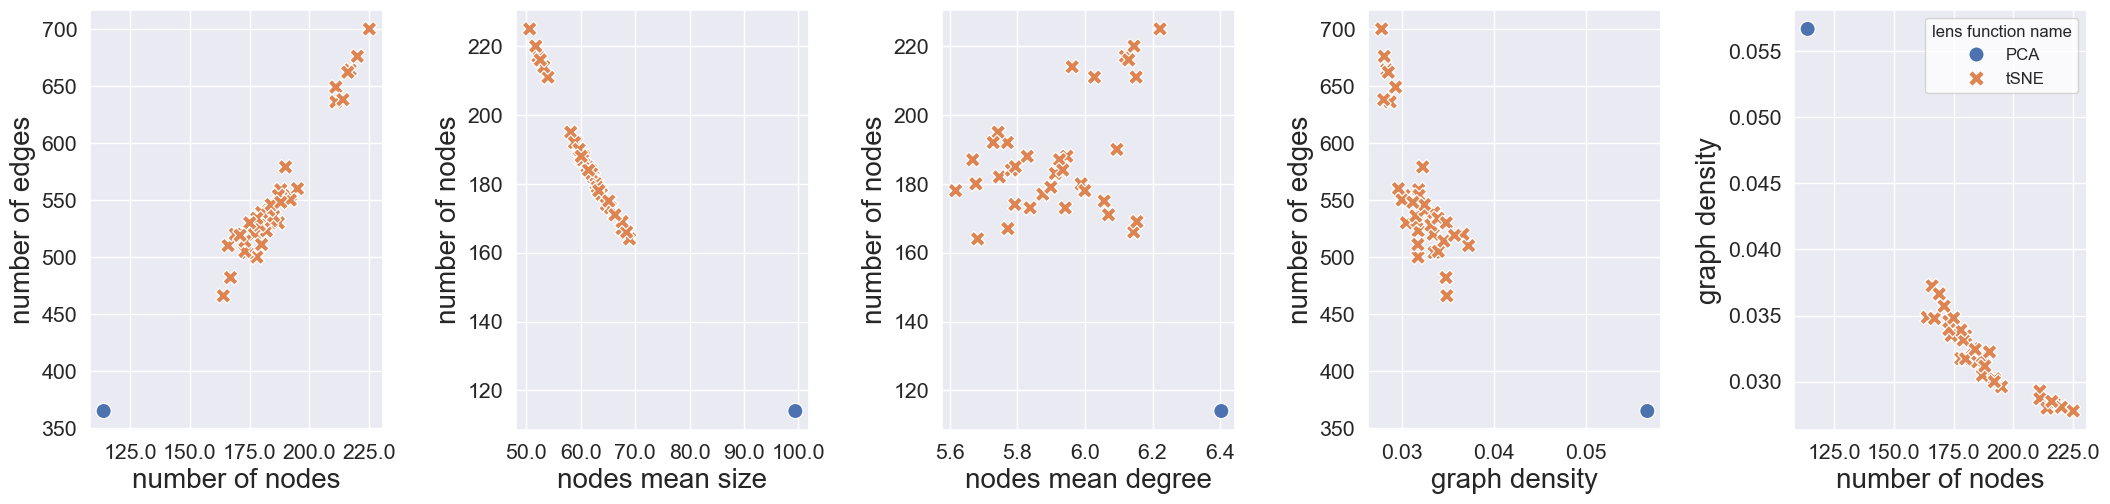

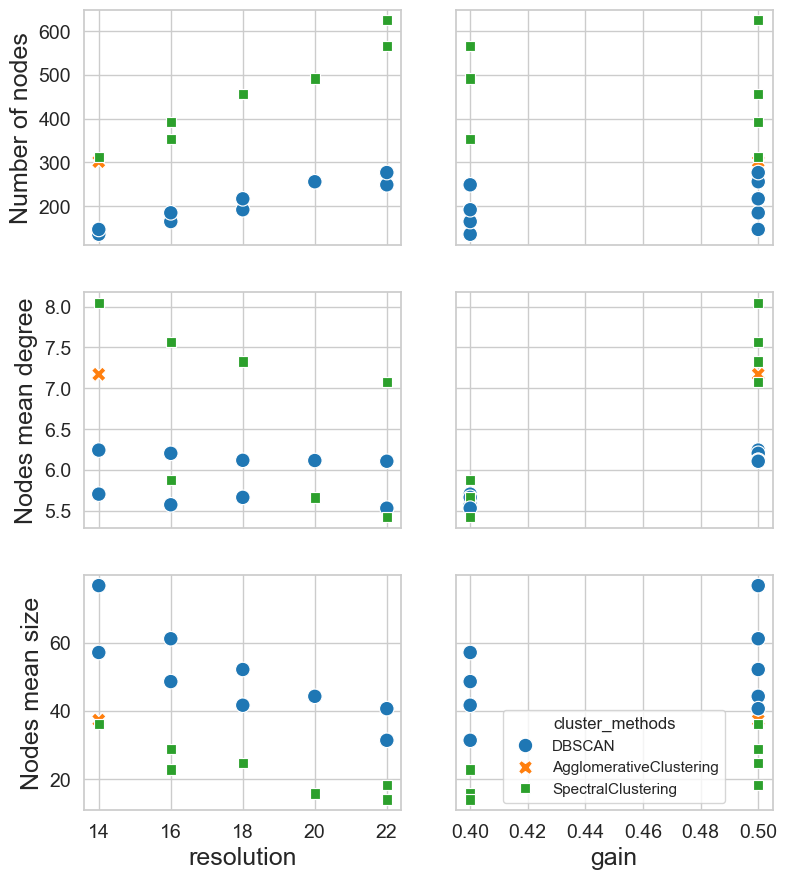

In [ ]:
dataset_path = "Dataset_TO_TDA.xlsx"  

initial_class = "CLASSIFICATION_NUM"          

make_the_class_binary = False
control_value = 0

random_seed = 203
patient_id = "Patient_ID"             
continue_features = 'Age_Years'     


list_lens_functions = ['PCA','tSNE']
n_dimension_projection = 2

tsne_perplexity = list( np.arange(10,60,10)) 
tsne_learning_rates =list( np.arange(300,1000,100)) 
tsne_n_iters = list(np.array([1500])) 

umap_min_dists = []
umap_n_neighbors = []

umapnn_n_neurons = []
umapnn_n_layers = []

umapae_nlayerdeep = []
umapae_nneurons_start = []

bio_lens = []

mapper_resolution =list( np.array([14, 16, 18, 20, 22]))
mapper_gain = list( np.array([0.2, 0.3, 0.4, 0.5])) 
mapper_cluster_method = ['DBSCAN','agglomerative_complete','agglomerative_average','agglomerative_single','spectral_clustering']

flag_remove_duplicate_nodes = True

# read the dataset
dataset = pd.read_excel(dataset_path)
dataset['Age_Years'] = dataset['Age_Years'].astype('float64')

   
# compute the distance matrix
distance_matrix = distance_matrix_computation(dataset[patient_id], dataset[initial_class], dataset, continue_features)

# perform the first step of the grid search by specifying the lens functions names and their hyperparameters. We fix the mapper parameters
first_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix, list_lens_functions, 
                                                                             n_dimension_projection, 
                                                                             make_the_class_binary, control_value,
                                                                      tsne_perplexity,tsne_learning_rates,tsne_n_iters,
                                                                      umap_min_dists,umap_n_neighbors,
                                                                      umapnn_n_neurons,umapnn_n_layers,  
                                                                      umapae_nlayerdeep,umapae_nneurons_start,       
                                                                      np.array([18]),np.array([0.5]), 
                                                                      ['DBSCAN'],
                                                                      random_seed, dataset[initial_class], 
                                dataset[bio_lens], "./lens_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)

# read and plot the results of the first grid search
grid_search_results_df = grid_search_results_optimal_choice("./lens_parameters_grid_search.xlsx",dataset[initial_class],distance_matrix,n_dimension_projection,
                                       random_seed,dataset[bio_lens],False, flag_remove_duplicate_nodes)
    

# filter the results 
grid_search_results_df = grid_search_results_df[~grid_search_results_df['nodes_degree'].apply(lambda x: 0 in x)]
grid_search_results_df = grid_search_results_df[grid_search_results_df['n_unique']==dataset.shape[0]]

final_min_entropy_index = grid_search_results_df['graph_entropy'].idxmin()
final_lens = grid_search_results_df.loc[final_min_entropy_index]['lens_name']
final_param_min_entropy = grid_search_results_df.loc[final_min_entropy_index]['parameters_combination']
    
if final_lens=="PCA":

    # perform the second step of the grid search 
    second_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix,
                [final_lens], n_dimension_projection, make_the_class_binary, control_value,
                [],[],[],  [],[],    [],[],   [],[],            
                mapper_resolution,mapper_gain, mapper_cluster_method,
                random_seed,dataset[initial_class],dataset[bio_lens], "./mapper_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)
    
elif final_lens=="tSNE":
    p = int(final_param_min_entropy.split(";")[0].split(": ")[1])
    l = int(final_param_min_entropy.split(";")[1].split(": ")[1])
    i = int(final_param_min_entropy.split(";")[2].split(": ")[1])

    # perform the second step of the grid search 
    second_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix,
                [final_lens], n_dimension_projection, make_the_class_binary, control_value,
                [p],[l],[i],  [],[],    [],[],   [],[],            
                mapper_resolution,mapper_gain, mapper_cluster_method,
                random_seed,dataset[initial_class],dataset[bio_lens], "./mapper_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)
        
elif final_lens=="UMAP":
    n = int(final_param_min_entropy.split(";")[1].split(": ")[1])
    d = float(final_param_min_entropy.split(";")[0].split(": ")[1])

    # perform the second step of the grid search 
    second_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix,
                [final_lens], n_dimension_projection, make_the_class_binary, control_value,
                [],[],[],  [n],[d],    [],[],   [],[],            
                mapper_resolution,mapper_gain, mapper_cluster_method,
                random_seed,dataset[initial_class],dataset[bio_lens], "./mapper_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)

elif final_lens=="UMAPnn": 
    nN = int(final_param_min_entropy.split(";")[0].split(": ")[1])
    nl = int(final_param_min_entropy.split(";")[1].split(": ")[1])

    # perform the second step of the grid search 
    second_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix,
                [final_lens], n_dimension_projection, make_the_class_binary, control_value,
                [],[],[],  [],[],    [nN],[nl],   [],[],            
                mapper_resolution,mapper_gain, mapper_cluster_method,
                random_seed,dataset[initial_class],dataset[bio_lens], "./mapper_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)
          
elif final_lens=="UMAPae":
    ndeep = int(final_param_min_entropy.split(";")[0].split(": ")[1])
    init_dim = int(final_param_min_entropy.split(";")[1].split(": ")[1])     

    # perform the second step of the grid search 
    second_step_grid_search_results_df = lenses_and_hyperparameters_greedy_search(distance_matrix,
                [final_lens], n_dimension_projection, make_the_class_binary, control_value,
                [],[],[],  [],[],    [],[],   [ndeep],[init_dim],            
                mapper_resolution,mapper_gain, mapper_cluster_method,
                random_seed,dataset[initial_class],dataset[bio_lens], "./mapper_parameters_grid_search.xlsx",flag_remove_duplicate_nodes)
    
# evaluate and plot the Mapper hyperparameters tuning
second_step_df_plot = evaluate_seach_Mapper_parameters("./mapper_parameters_grid_search.xlsx",dataset.shape[0])

# we can manually filter second_step_df_plot to select the best configuration of mapper hyperparameters. Eg.:
#second_step_df_plot[(second_step_df_plot['n_nodes']>=200) & (second_step_df_plot['n_nodes']<=400) & (second_step_df_plot['mean degree']>=6) & (second_step_df_plot['mean degree']<=14) & (second_step_df_plot['mean size']>=6) & (second_step_df_plot['mean size']<=12)]

final_min_entropy_index = second_step_df_plot['graph_entropy'].idxmin()
final_lens = second_step_df_plot.loc[final_min_entropy_index]['lens_name']
final_param_min_entropy = second_step_df_plot.loc[final_min_entropy_index]['parameters_combination']

extract_parameters_from_string_and_project_or_graph(
    final_lens, distance_matrix, final_param_min_entropy, n_dimension_projection, random_seed, bio_lens, flag_remove_duplicate_nodes, "graph"
        )


## Distance matrix plot

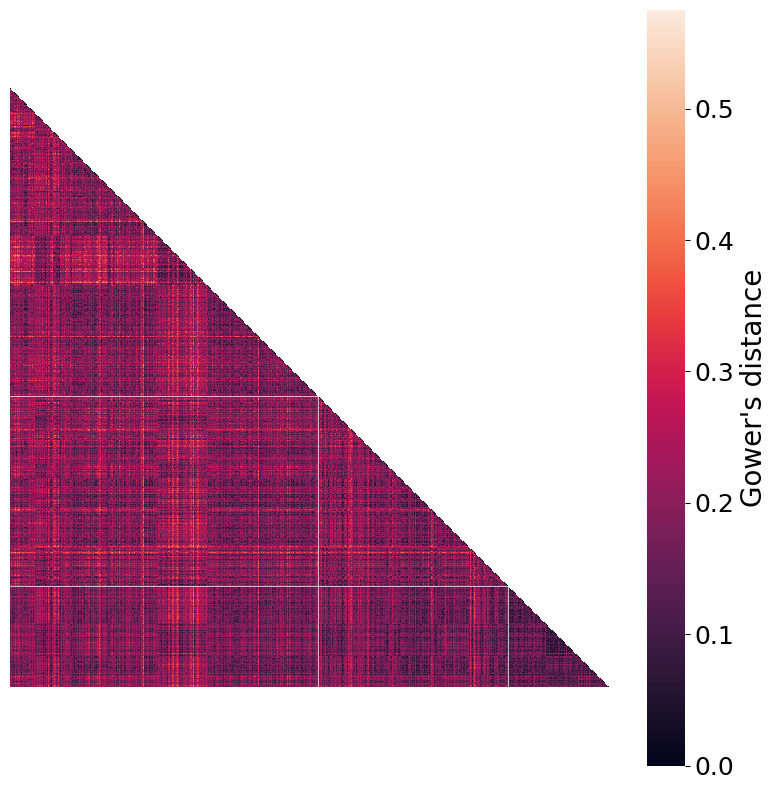

Within-group distance stats:
Class 2: 1500 items, 1124250 pairs | mean=0.2089, std=0.0674, min=0.0000, max=0.5752
Class 1: 928 items, 430128 pairs | mean=0.1922, std=0.0624, min=0.0000, max=0.4869
Class 0: 494 items, 121771 pairs | mean=0.1325, std=0.0504, min=0.0000, max=0.3644


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# --- Prepare labels and sorting ---
labels = dataset['CLASSIFICATION_NUM'].to_numpy()

# enforce a specific class order
class_order = [2, 1, 0]
cats = pd.Categorical(labels, categories=class_order, ordered=True)
codes = cats.codes  # integer code per class

# Stable sort by class so equal labels keep original order
perm = np.argsort(codes, kind="stable")

# Reindex the matrix (rows and columns) with the same permutation
D_sorted = distance_matrix[np.ix_(perm, perm)]

# Reindex labels after sorting so we know which row/col belongs to which class
labels_sorted = labels[perm]
codes_sorted = codes[perm]

# Compute boundaries between classes (for optional grid lines in the plot)
boundaries = np.flatnonzero(np.diff(codes_sorted)) + 1  # indices where class changes

# --- Mask the UPPER triangle (so we only see the LOWER triangle in the heatmap) ---
mask = np.triu(np.ones_like(D_sorted, dtype=bool), k=1)

# --- Plot ---
plt.figure(figsize=(8, 8))
ax = sb.heatmap(
    D_sorted,
    mask=mask,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={'label': "Gower's distance"}
)

# Optional: draw thin lines at class boundaries
for b in boundaries:
    ax.axhline(b, color='white', linewidth=0.5)
    ax.axvline(b, color='white', linewidth=0.5)

# Style the colorbar
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.label.set_size(20)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
#plt.savefig("./distance_matrix_lower_triangle.png", dpi=330, bbox_inches='tight')
plt.show()

# ======================
#  STATS PER GROUP
# ======================

stats_list = []

for cls in class_order:
    # indices in this class (after sorting)
    idx = np.where(labels_sorted == cls)[0]

    if len(idx) < 2:
        # Can't compute distances with fewer than 2 items
        stats_list.append({
            "class": cls,
            "n_items": len(idx),
            "n_pairs": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
        })
        continue

    # extract the submatrix for this group
    submat = D_sorted[np.ix_(idx, idx)]

    # take only the strict lower triangle (i>j) so we don't double count pairs or include diagonal
    tri_i, tri_j = np.tril_indices(len(idx), k=-1)
    dists = submat[tri_i, tri_j]

    stats_list.append({
        "class": cls,
        "n_items": len(idx),
        "n_pairs": len(dists),
        "mean": float(np.mean(dists)),
        "std": float(np.std(dists, ddof=1)) if len(dists) > 1 else np.nan,
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
    })

# Pretty-print results
print("Within-group distance stats:")
for row in stats_list:
    cls = row["class"]
    n_items = row["n_items"]
    n_pairs = row["n_pairs"]
    mean = row["mean"]
    std = row["std"]
    dmin = row["min"]
    dmax = row["max"]

    # Format nicely, handling NaNs
    mean_str = f"{mean:.4f}" if not np.isnan(mean) else "nan"
    std_str  = f"{std:.4f}" if not np.isnan(std) else "nan"
    min_str  = f"{dmin:.4f}" if not np.isnan(dmin) else "nan"
    max_str  = f"{dmax:.4f}" if not np.isnan(dmax) else "nan"

    print(
        f"Class {cls}: "
        f"{n_items} items, {n_pairs} pairs | "
        f"mean={mean_str}, std={std_str}, min={min_str}, max={max_str}"
    )


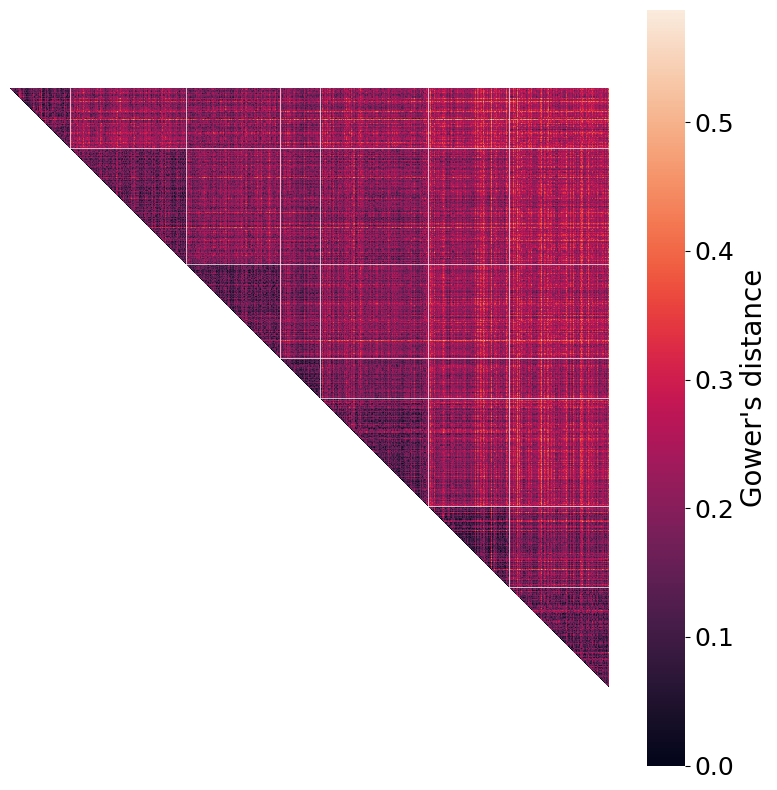

Within-community distance stats (dataset_t1 / communities):
Community 1: 291 items, 42195 pairs | mean=0.1548, std=0.0598, min=0.0000, max=0.4111
Community 2: 569 items, 161596 pairs | mean=0.1636, std=0.0598, min=0.0000, max=0.4825
Community 3: 457 items, 104196 pairs | mean=0.1392, std=0.0539, min=0.0000, max=0.4048
Community 4: 194 items, 18721 pairs | mean=0.1323, std=0.0509, min=0.0000, max=0.3381
Community 5: 528 items, 139128 pairs | mean=0.1516, std=0.0538, min=0.0000, max=0.4111
Community 6: 392 items, 76636 pairs | mean=0.1409, std=0.0601, min=0.0000, max=0.4762
Community 7: 491 items, 120295 pairs | mean=0.1634, std=0.0615, min=0.0000, max=0.4413


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# --- Prepare labels & ordering ---
labels = dataset_t1['communities'].to_numpy()
class_order = [1, 2, 3, 4, 5, 6, 7]

cats = pd.Categorical(labels, categories=class_order, ordered=True)
codes = cats.codes  # integer code per class

# Stable sort by class so equal labels keep original order
perm = np.argsort(codes, kind="stable")

# Reindex the matrix (rows and columns) with the same permutation
D_sorted = distance_matrix_t1[np.ix_(perm, perm)]

# Reindex labels after sorting (so rows/cols line up with heatmap)
labels_sorted = labels[perm]
codes_sorted = codes[perm]

# Compute boundaries between classes (for optional grid lines)
boundaries = np.flatnonzero(np.diff(codes_sorted)) + 1

# --- Mask the LOWER triangle to show only upper triangle ---
mask = np.tril(np.ones_like(D_sorted, dtype=bool), k=-1)
# np.tril(..., k=-1) masks strictly below the diagonal (keeps diagonal visible)
# use k=0 if you also want to hide the diagonal

# --- Plot ---
plt.figure(figsize=(8,8))
ax = sb.heatmap(
    D_sorted,
    mask=mask,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={'label': "Gower's distance"}
)

# Optional: draw thin lines at class boundaries
for b in boundaries:
    ax.axhline(b, color='white', linewidth=0.5)
    ax.axvline(b, color='white', linewidth=0.5)

# Style colorbar
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.label.set_size(20)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
#plt.savefig("./distance_matrix_t1_upper_triangle.png", dpi=330, bbox_inches='tight')
plt.show()

# ======================
#  STATS PER COMMUNITY
# ======================

stats_list = []

for cls in class_order:
    # indices (in the *sorted* order) that belong to this community
    idx = np.where(labels_sorted == cls)[0]

    if len(idx) < 2:
        # can't form pairs with <2 items, so fill with NaN
        stats_list.append({
            "class": cls,
            "n_items": len(idx),
            "n_pairs": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
        })
        continue

    # take the class-specific block of the sorted matrix
    submat = D_sorted[np.ix_(idx, idx)]

    # get unique pairs (i>j) to avoid duplicates and skip diagonal
    tri_i, tri_j = np.tril_indices(len(idx), k=-1)
    dists = submat[tri_i, tri_j]

    stats_list.append({
        "class": cls,
        "n_items": len(idx),
        "n_pairs": len(dists),
        "mean": float(np.mean(dists)),
        "std": float(np.std(dists, ddof=1)) if len(dists) > 1 else np.nan,
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
    })

# Nicely formatted printout
print("Within-community distance stats (dataset_t1 / communities):")
for row in stats_list:
    cls      = row["class"]
    n_items  = row["n_items"]
    n_pairs  = row["n_pairs"]
    mean     = row["mean"]
    std      = row["std"]
    dmin     = row["min"]
    dmax     = row["max"]

    mean_str = f"{mean:.4f}" if not np.isnan(mean) else "nan"
    std_str  = f"{std:.4f}"  if not np.isnan(std)  else "nan"
    min_str  = f"{dmin:.4f}" if not np.isnan(dmin) else "nan"
    max_str  = f"{dmax:.4f}" if not np.isnan(dmax) else "nan"

    print(
        f"Community {cls}: "
        f"{n_items} items, {n_pairs} pairs | "
        f"mean={mean_str}, std={std_str}, min={min_str}, max={max_str}"
    )
